In [4]:
from genericpath import isfile

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import joblib

import sys
sys.path.append('/home/reabt/experiments/ncc/MRI/code/')
from utils.load_cfg import load_MRI_config_instance
from utils.plots import *

In [ ]:

def plot_partial_mask(maskNr):
	config_class_name = 'MRIconfig_C5'

	cfg = load_MRI_config_instance(config_class_name, '20010917rswg', maskNr=0)
	cfg.configure_paths()
	full_mask = nib.load(cfg.get_mask_file())
	cfg = load_MRI_config_instance(config_class_name, '20010917rswg', maskNr=maskNr)
	cfg.configure_paths()
	partial_mask = nib.load(cfg.get_mask_file())

	plotting.plot_stat_map(
	    partial_mask,
	    bg_img=full_mask,  # Use the original image as the background
	    threshold=0.1,  # Lower threshold to ensure visibility
	    display_mode="ortho",  # Orthogonal view
	    colorbar=True,
	    cmap='Greens',
	    vmax=1,  # Maximum value for the colorbar
	    alpha = 0.9,
	    black_bg="False"
	)
	plotting.show()

Full brain max fit

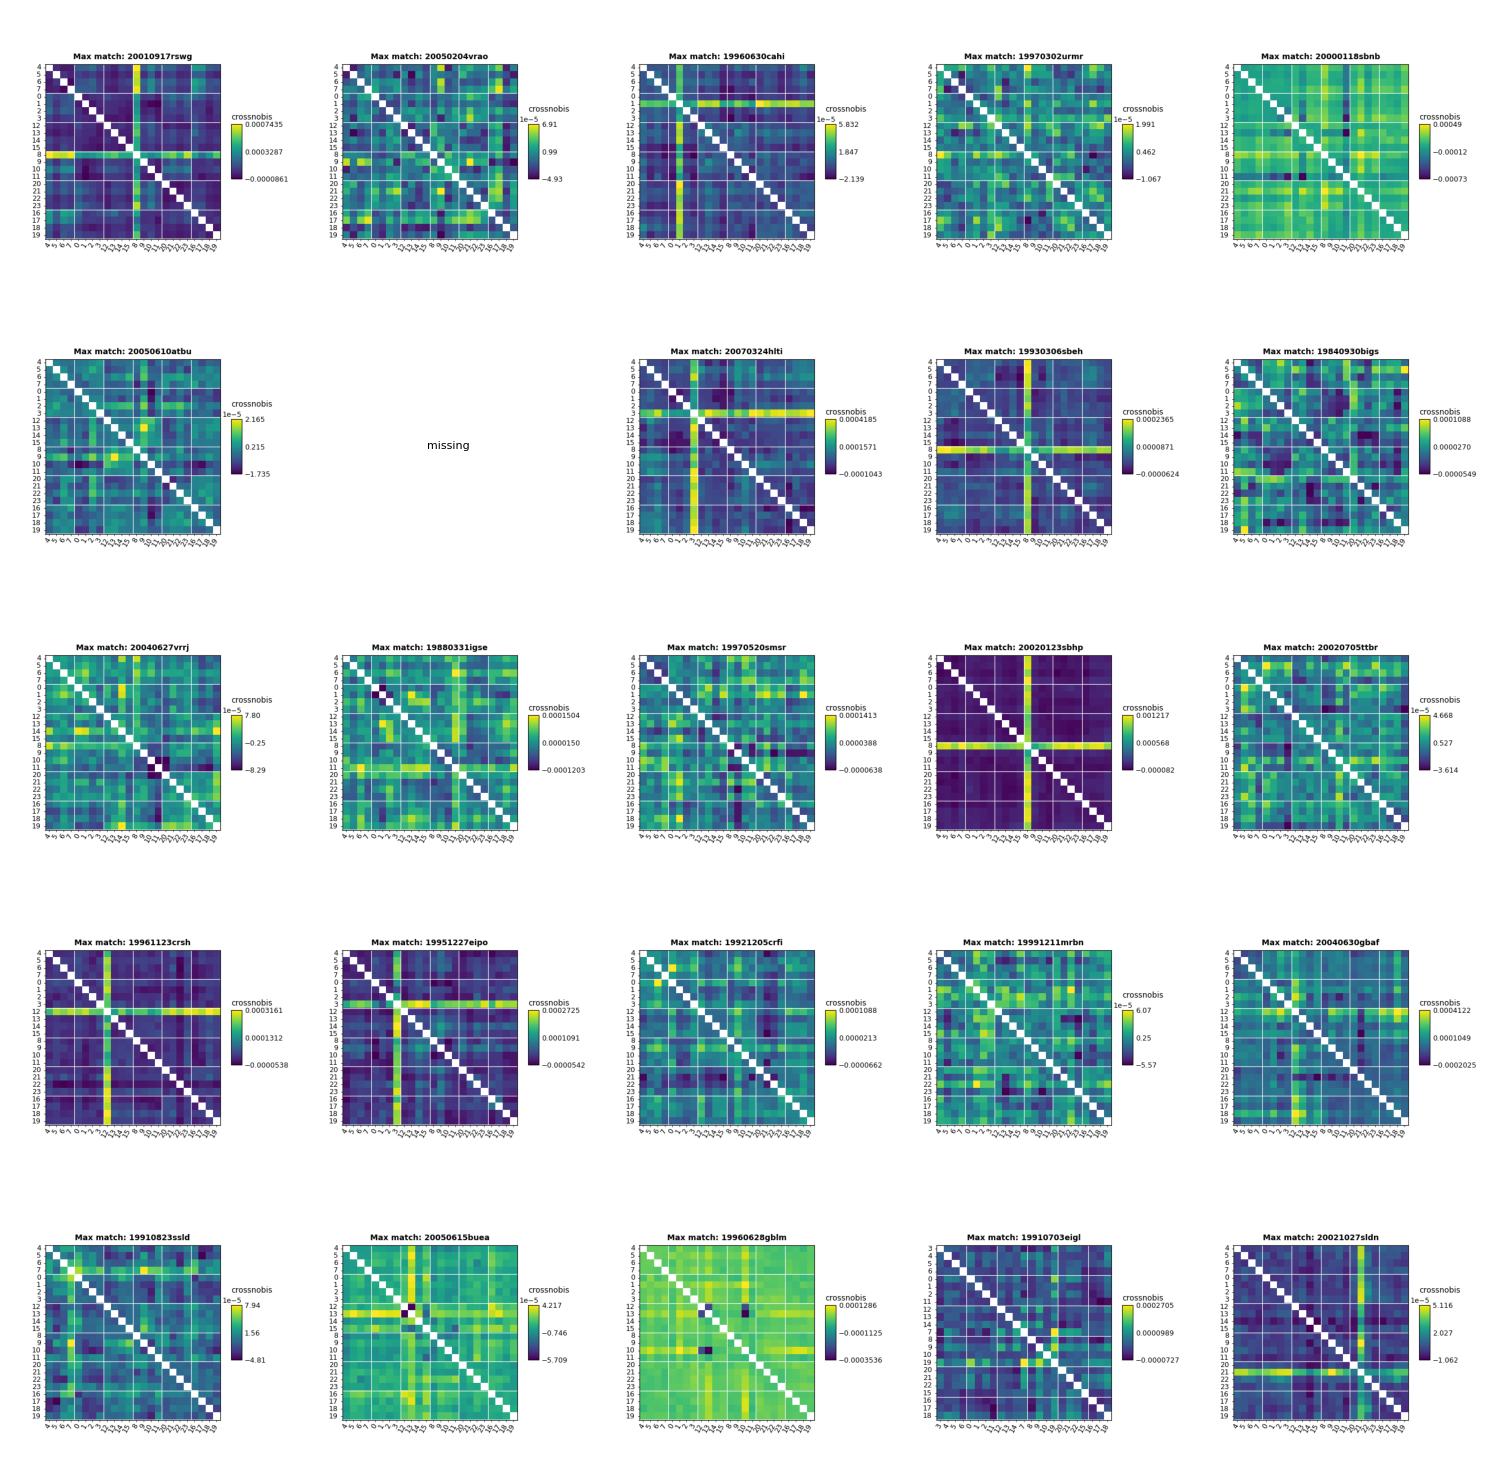

In [9]:
inDir = '/home/reabt/experiments/ncc/MRI/data/rsa/MRIconfig_C5/'
os.listdir(inDir)
subjectIDs = [d for d in os.listdir(inDir) if os.path.isdir(os.path.join(inDir, d)) and len(d) == 12 and d[:8].isdigit() and d[8:].isalpha()]
fileName = "fullBrain_SL_C5_SM1C_24Cond_crossnobis_corr_cov_r5_thr1_suprasensory_RDM_maxFit_suprasensory.png"

n = len(subjectIDs)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
plt.tight_layout()
axes = axes.flatten()

for i, subj in enumerate(subjectIDs):
	image_path = os.path.join(inDir, subj, fileName)
	if os.path.isfile(image_path):
		img = mpimg.imread(image_path)
		axes[i].imshow(img)
		# axes[i].set_title(subj, fontsize=8)
	else:
		axes[i].text(0.5, 0.5, "missing", ha="center", va="center", fontsize=8)
	axes[i].axis("off")

for j in range(n, len(axes)):
	axes[j].axis("off")

plt.tight_layout()
plt.show()

In [ ]:

from matplotlib.ticker import FuncFormatter

# define custom formatter:
# - values < 0.01 -> scientific notation
# - otherwise -> normal decimal
def sci_formatter(x, pos):
	if abs(x) < 1e-2 and x != 0:
		return f"{x:.1e}"   # e.g. 3.2e-03
	else:
		return f"{x:.2f}"   # e.g. 0.12
	

def plot_max_modelFit_rdm2(cfg, SL_rdms, eval_score, fig=None, ax=None):
	import matplotlib.pyplot as plt

	voxel_indices = SL_rdms.rdm_descriptors['voxel_index']

	max_value = np.max(eval_score)
	max_idx = int(np.argmax(eval_score))
	max_voxel = voxel_indices[max_idx]
	max_rdm_idx = np.where(SL_rdms.rdm_descriptors['voxel_index'] == max_voxel)[0][0]

	# pattern_descriptor = 'index'
	pattern_descriptor = 'condition'

	if ax is None:
		fig, ax = plt.subplots(figsize=(5, 5))

	# create temporary rsa figure
	rsaFig = rsa.vis.show_rdm(
		SL_rdms[max_rdm_idx],
		# pattern_descriptor=pattern_descriptor,
		pattern_descriptor=None,
		rdm_descriptor=cfg.subjectID,
		num_pattern_groups=4,
		cmap='viridis',
		show_colorbar='panel',
	)

	fig_tmp, axes_arr, meta = rsaFig
	img = meta[0]['image']
	cbar_tmp = meta[0]['colorbar']  # <-- important

	# extract image
	img_new = ax.imshow(
		img.get_array(),
		cmap=img.get_cmap(),
		norm=img.norm,
		extent=img.get_extent(),
		origin=img.origin,
		interpolation=img.get_interpolation()
	)

	# labels
	# x_labels = [t.get_text() for t in meta[0]['x_labels']]
	# y_labels = [t.get_text() for t in meta[0]['y_labels']]

	# ax.set_xticks(range(len(x_labels)))
	# ax.set_xticklabels(x_labels, rotation=90)
	# ax.set_yticks(range(len(y_labels)))
	# ax.set_yticklabels(y_labels)
	# ax.set_title(axes_arr[0, 0].get_title())

	# --- COLORBAR FIX ---
	# recreate colorbar WITHOUT triggering new figure issues
	# (do NOT reuse cbar_tmp directly)
	# cbar = fig.colorbar(img_new, ax=ax, fraction=0.026, pad=0.004)
	# if cbar_tmp.ax.get_ylabel():	# copy label if present
	# 	cbar.set_label(cbar_tmp.ax.get_ylabel())

	# close temporary figure AFTER everything is copied
	plt.close(fig_tmp)

	return img_new


def plot_max_rdm_of_mask(maskNr):
	print(maskNr)
	fig, axes = plt.subplots(5, 5, figsize=(10, 10))
	fig.suptitle(f'maskNr: {maskNr}', y=1.01, fontsize = 18, fontweight = 'bold')
	plt.tight_layout()
	axes = axes.flatten()

	for i, subjectID in enumerate(subjectIDs):

		config_class_name = 'MRIconfig_C5'
			
		cfg = load_MRI_config_instance(config_class_name, subjectID, maskNr=maskNr)

		sl_file = cfg.get_outFile_names()['SL_rdms']
		# print(cfg.get_outFile_names())
		eval_file = cfg.get_outFile_names()['eval_results']

		if os.path.isfile(sl_file):

			SL_rdms = joblib.load(sl_file)
			eval_results = joblib.load(eval_file)

			cfg.modelType = 'suprasensory'
			cfg.configure_paths()

			eval_score = [float(e.evaluations[0][cfg.modelIdx].item()) for e in eval_results]
			voxel_indices = SL_rdms.rdm_descriptors['voxel_index']

			# Determine max voxel and its index in RDM
			max_idx = int(np.argmax(eval_score)) # find max eval_score
			max_voxel = voxel_indices[max_idx] # find voxel index of the max eval score
			max_rdm_idx = np.where(SL_rdms.rdm_descriptors['voxel_index'] == max_voxel)[0][0] # find indx of voxel index in compiles SL_rdms

			
			plot_max_modelFit_rdm2(cfg, 
								SL_rdms, 
								eval_score, fig, axes[i])
	fileName = f'/home/reabt/experiments/ncc/MRI/code/cluster_outputs/partial_masks_max_rdm/C5_maskNr_{maskNr}.png'
	plt.savefig(fileName)
	# plt.show()
	plt.close()

3


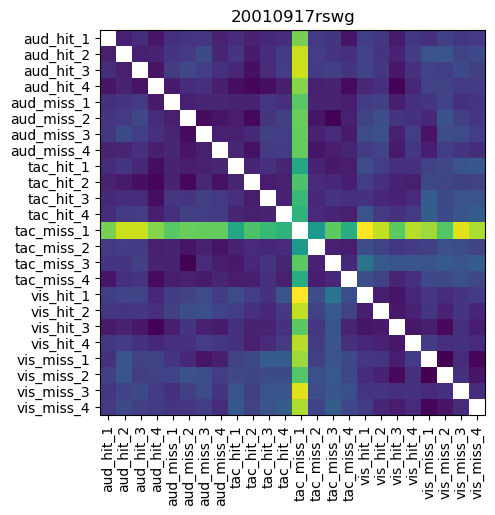

In [ ]:
maskNr = 3
print(maskNr)

subjectID = subjectIDs[0] 
config_class_name = 'MRIconfig_C5'
	
cfg = load_MRI_config_instance(config_class_name, subjectID, maskNr=maskNr)

sl_file = cfg.get_outFile_names()['SL_rdms']
# print(cfg.get_outFile_names())
eval_file = cfg.get_outFile_names()['eval_results']

if os.path.isfile(sl_file):

	SL_rdms = joblib.load(sl_file)
	eval_results = joblib.load(eval_file)

	cfg.modelType = 'suprasensory'
	cfg.configure_paths()

	eval_score = [float(e.evaluations[0][cfg.modelIdx].item()) for e in eval_results]
	voxel_indices = SL_rdms.rdm_descriptors['voxel_index']

	# Determine max voxel and its index in RDM
	max_idx = int(np.argmax(eval_score)) # find max eval_score
	max_voxel = voxel_indices[max_idx] # find voxel index of the max eval score
	max_rdm_idx = np.where(SL_rdms.rdm_descriptors['voxel_index'] == max_voxel)[0][0] # find indx of voxel index in compiles SL_rdms

	
	plot_max_modelFit_rdm2(cfg, 
						SL_rdms, 
						eval_score, fig)
fileName = f'/home/reabt/experiments/ncc/MRI/code/cluster_outputs/partial_masks_max_rdm/C5_maskNr_{maskNr}.png'
# plt.savefig(fileName)
plt.show()
# plt.close()

# plot_max_rdm_of_mask(3)

## plot all partial masks and save them

In [ ]:
# for i in range(1, 61):
#     # if i not in [5, 16, 20, 25, 36, 40, 45]:
#     plt.close()
#     plot_max_rdm_of_mask(i)

## plot partial mask

/tmp/ipykernel_1630957/3655109015.py:13: UserWarning: kwargs['alpha']=0.9 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value via the 'transparency' parameter.
  plotting.plot_stat_map(


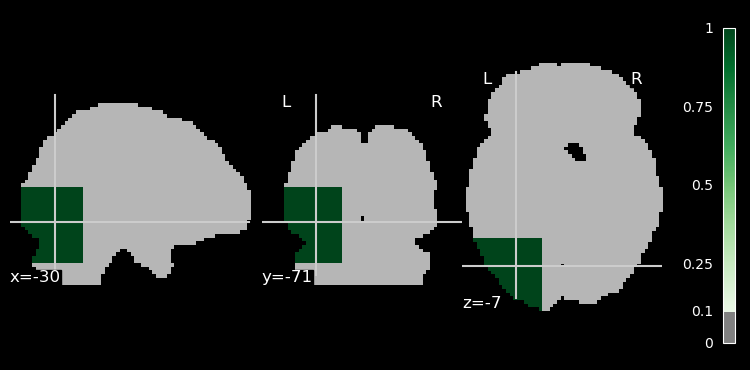

In [17]:
maskNr = 42
plot_partial_mask(maskNr)

# Euclidean suprasensory max fit

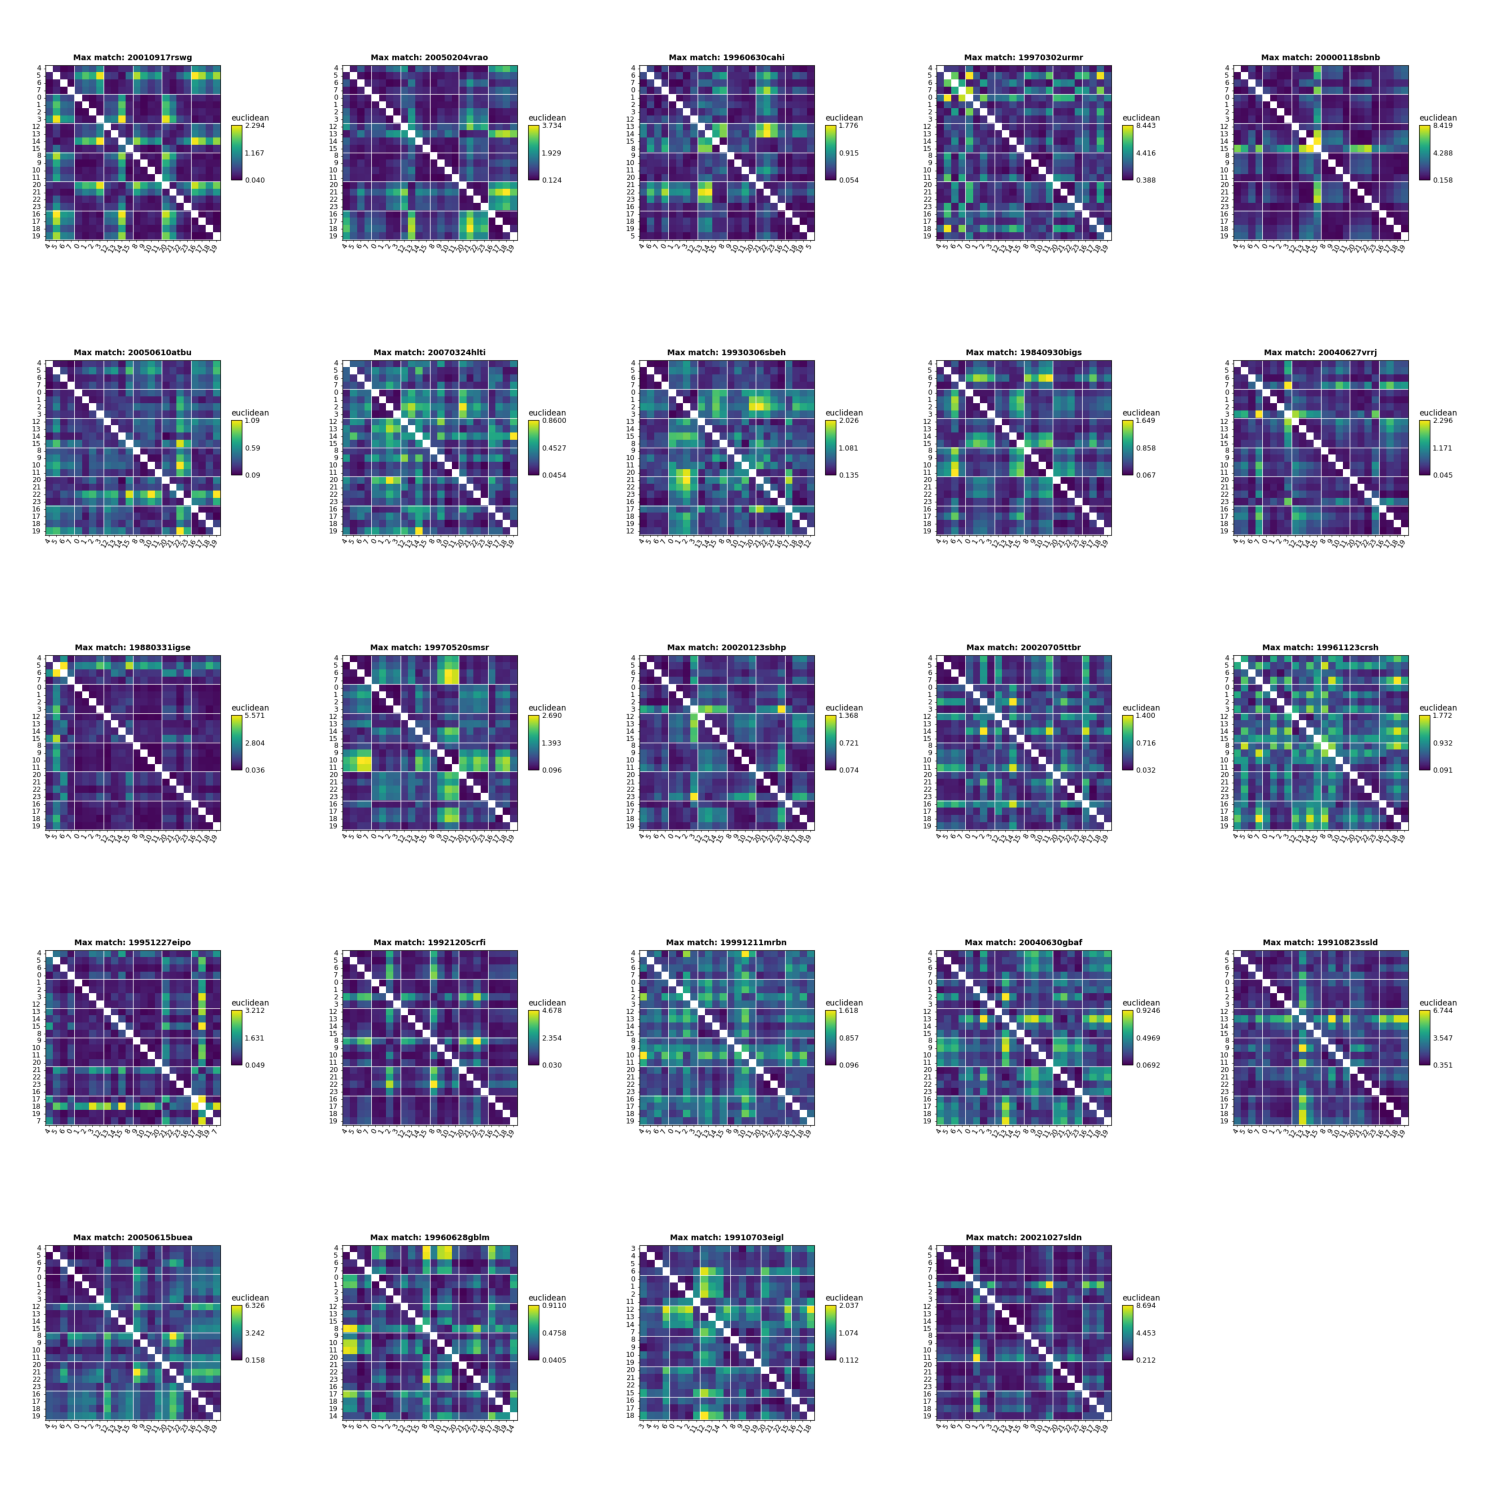

In [8]:


inDir = '/home/reabt/experiments/ncc/MRI/data/rsa/MRIconfig_E5/'
os.listdir(inDir)
subjectIDs = [d for d in os.listdir(inDir) if os.path.isdir(os.path.join(inDir, d)) and len(d) == 12 and d[:8].isdigit() and d[8:].isalpha()]
fileName = "fullBrain_SL_E5_SM1C_24Cond_euclidean_spearman_r5_thr0_5_suprasensory_RDM_maxFit_suprasensory.png"

n = len(subjectIDs)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
plt.tight_layout()
axes = axes.flatten()

for i, subj in enumerate(subjectIDs):
	image_path = os.path.join(inDir, subj, fileName)
	if os.path.isfile(image_path):
		img = mpimg.imread(image_path)
		axes[i].imshow(img)
		# axes[i].set_title(subj, fontsize=8)
	else:
		axes[i].text(0.5, 0.5, "missing", ha="center", va="center", fontsize=8)
	axes[i].axis("off")

for j in range(n, len(axes)):
	axes[j].axis("off")

plt.tight_layout()
plt.show()